### Playing with data
Aims of exploratory data anlysis, explore relationships between:
- Rainfall descriptors (event volume, is this the only rainfall characteristic?)
- Flooding outcomes ()
- Catchment descriptors
- Antecedent soil moisture conditions (mean value over catchment?, would there be a way to find mean value more specifically over the peak of the rainfall event )

In [1]:
def mask_to_catchment(cube, catchment):

    catchment_proj = catchment.to_crs(epsg=27700)
    
    # Extract coordinates
    x = cube.coord('projection_x_coordinate').points
    y = cube.coord('projection_y_coordinate').points
    
    # Create 2D meshgrid of coordinates
    xx, yy = np.meshgrid(x, y)
    
    # Flatten coordinates
    points = np.vstack((xx.ravel(), yy.ravel())).T
    
    # Get catchment geometry
    catchment_geom = catchment_proj.geometry.iloc[0]
    
    # Test which grid cells are inside catchment
    mask = np.array([catchment_geom.contains(Point(pt)) for pt in points])
    
    # Reshape to grid
    mask = mask.reshape(len(y), len(x))
    return mask

## Get catchment data

In [2]:
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt
from scipy import stats
import os
import numpy as np
import contextily as ctx
import iris
import iris.quickplot as qplt
import iris.plot as iplt
import iris.coord_categorisation
from shapely.geometry import Point
import glob
import cartopy.crs as ccrs
import pickle 
import cftime

home_dir = "C:/Users/kv25483/OneDrive - University of Bristol/FutureFlood/Data/"
home_dir = "/scratch/hydro4/users/" # kv25483/"

### Read in spatial outline of catchments, and get just Newcastle

In [3]:
catchments = gpd.read_file(home_dir + "kv25483/FutureFlood/Data/NewcastleExample/catchment_identifier/hyd_areas_GB_with_subcatchments.shp")
newcastle = catchments[catchments['HA_NUM'] == "23"]
# newcastle.plot()

## Get soil data for one ensemble member over UK, joined into one cube
From 1980 to 2080

In [4]:
# Get a list of all the filenames for this EM
filenames = []
for filename in glob.glob("/scratch/hydro4/shared_data/climate_projections/UKCP18/UKCP_local/Soil_moisture/5km_regridded/Ens_01/*"):
    filenames.append(filename)
# Convert to an iris cubelist
cube_list = iris.load(filenames)
# Concatenate into one cube
model_cube = cube_list.concatenate_cube()  

In [5]:
model_cube

<iris 'Cube' of moisture_content_of_soil_layer / (kg m-2) (time: 36000; projection_y_coordinate: 244; projection_x_coordinate: 180)>

Plot to check

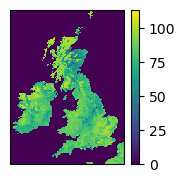

In [5]:
# Get projection from cube
cube_slice = model_cube[1,:,:]
proj = cube_slice.coord_system().as_cartopy_projection()
fig = plt.figure(figsize=(2,2))
ax = plt.axes(projection=proj)
mesh = iplt.pcolormesh(model_cube[1])
plt.colorbar(mesh, ax=ax);

### Get the dates in human readable (and plottable) format

In [19]:
iris.FUTURE.date_microseconds = True
# Get a list of dates covered by the soil moisture data
def create_datetime_dates_from_cube(cube):
    time_coord = cube.coord('time')
    dates = time_coord.units.num2date(time_coord.points)
    time_numeric = cube.coord('time').points
    dates = pd.to_datetime("1970-01-01") + pd.to_timedelta(time_numeric, unit='h')
    return dates 
dates = create_datetime_dates_from_cube(model_cube)
dates[:4]

years = dates.year
years[:4]

Index([1980, 1980, 1980, 1980], dtype='int32')

## Mask the data to the Newcastle catchment

In [7]:
mask = mask_to_catchment(model_cube, newcastle)

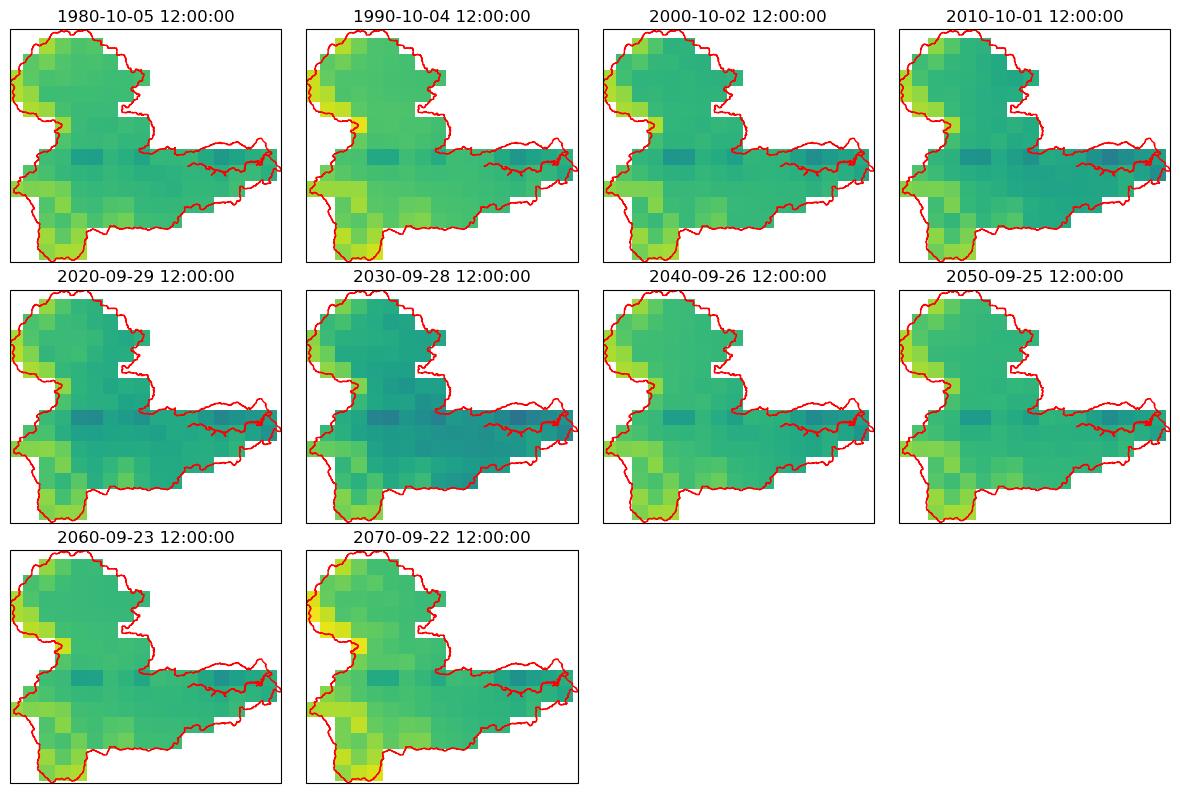

In [10]:
# # timesteps = [0, 30, 60, 90, 120, 150, 180, 210, 250, 280]
# timesteps = list(range(0,1825*12,1825))
# timesteps = list(range(0,3651*10,3651))
# # timesteps = [0, 90, 180, 270, 360, 430, 520, 610, 700, 790, 880, 980]

# vmax=0, 
# vmin=0
# for i, t in enumerate(timesteps, 1):
    
#     cube_slice = model_cube[t,:,:].copy()
#     vmin_slice = np.nanmin(cube_slice.data)
#     vmax_slice = np.nanmax(cube_slice.data)
#     if vmax_slice>vmax:
#         vmax =vmax_slice
# # print(vmin, vmax)

# plt.figure(figsize=(12, 8))

# for i, t in enumerate(timesteps, 1):

#     plt.subplot(3, 4, i)   # 2 rows, 3 columns
    
#     cube_slice = model_cube[t,:,:].copy()
#     time = create_datetime_dates_from_cube(cube_slice)[0]
#     data = cube_slice.data.astype(float)
#     data[~mask] = np.nan
#     cube_slice.data = data

#     mesh = iplt.pcolormesh(cube_slice, vmin=vmin, vmax=vmax)

#     xmin, ymin, xmax, ymax = newcastle.total_bounds
#     ax = plt.gca()
#     ax.set_xlim(xmin, xmax)
#     ax.set_ylim(ymin, ymax)

#     newcastle.boundary.plot(ax=ax, edgecolor="red", linewidth=1)

#     plt.title(f"{time}")

# plt.tight_layout()
# plt.show()

## Find the mean daily soil moisture over time in Newcastle catchment

### Find mean moisture over catchment (masking on the fly)

In [11]:
# The np.where condition means: Where grid cells are inside Newcastle → keep real soil moisture values
#                               Where grid cells outside Newcastle → replace with np.nan
# This creates (on the fly) a masked 3D array with shape: (nt, ny, nx), which isn't saved but is used in the np.nanmean() calculation
# np.nanmean() then calculates the mean value across ny, nx dimensions (i.e. across the catchment), ignoring any np.nan values 
# To produce an output of shape (,nt).
catchment_daily_mean = np.nanmean(np.where(mask, model_cube.data, np.nan), axis=(1, 2))

In [38]:
with open('../Data/catchment_daily_mean.pickle', 'wb') as handle:
    pickle.dump(catchment_daily_mean, handle, protocol=pickle.HIGHEST_PROTOCOL)

### Find the year which each of these mean values relate to, then split the mean values into three time periods

In [13]:
time_coord = model_cube.coord('time')
dates_coord = time_coord.units.num2date(time_coord.points)
years = np.array([d.year for d in dates_coord])

baseline = catchment_daily_mean[(years >= 1980) & (years < 2020)]
present  = catchment_daily_mean[(years >= 2020) & (years < 2050)]
future   = catchment_daily_mean[(years >= 2050) & (years < 2090)]

### Plot a histogram of the distribution of avg. catchment soil moisture in Newcastle for 3 time periods 

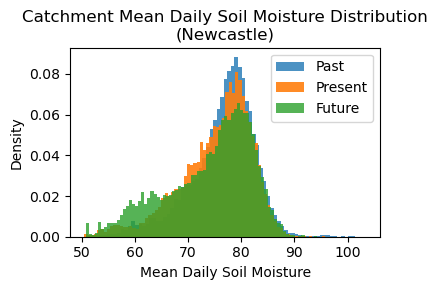

In [14]:
plt.figure(figsize=(4,3))

plt.hist(baseline, bins=75, density=True, alpha=0.8, label="Past")
plt.hist(present,  bins=75, density=True, alpha=0.9, label="Present")
plt.hist(future,   bins=75, density=True, alpha=0.8, label="Future")

plt.xlabel("Mean Daily Soil Moisture")
plt.ylabel("Density")
plt.title("Catchment Mean Daily Soil Moisture Distribution\n(Newcastle)")
plt.legend()
plt.tight_layout()
plt.show()

### Plot daily soil moisture over time
For one year

In [77]:
# one_year_events = events[events['start_year']==1992].copy()
# one_year_events['stop_datetime'] = (pd.to_datetime("1970-01-01") + pd.to_timedelta(one_year_events['stop_time'], unit='h'))
# one_year_events['start_datetime'] = (pd.to_datetime("1970-01-01") + pd.to_timedelta(one_year_events['start_time'], unit='h'))

In [24]:
daily_means = pd.DataFrame({'dates':dates, 'daily_means':catchment_daily_mean, 'year':years})
daily_means = daily_means.set_index('dates')
monthly_means = daily_means['daily_means'].resample('MS').mean()
monthly_means = (daily_means['daily_means'].resample('MS').mean().reset_index())
monthly_means['year'] = monthly_means['dates'].dt.year
monthly_means['month'] = monthly_means['dates'].dt.month
daily_means = pd.DataFrame({'dates':dates, 'daily_means':catchment_daily_mean, 'year':years})

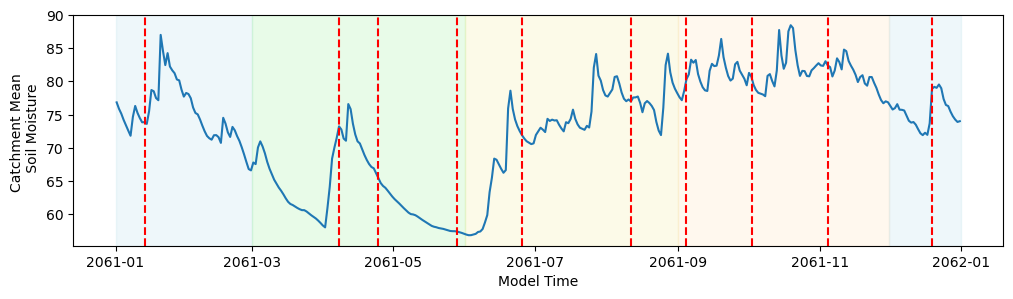

In [75]:
year=2061
one_year_events = events[events['start_year']==year].copy()
len(one_year_events)

fig,ax=plt.subplots(figsize=(12,3))
one_year = daily_means[daily_means['year']==year]
ax.plot(one_year['dates'], one_year['daily_means'])
ax.set_xlabel("Model Time")
ax.set_ylabel("Catchment Mean \n Soil Moisture")

event_dates= one_year_events['start_date']
if len(event_dates) >0:
    for event in event_dates:
        ax.axvline(event, color = 'red', linestyle='--');

# # Define season boundaries
winter_start = pd.Timestamp(f"{year}-01-01")
spring_start = pd.Timestamp(f"{year}-03-01")
summer_start = pd.Timestamp(f"{year}-06-01")
autumn_start = pd.Timestamp(f"{year}-09-01")
winter2_start = pd.Timestamp(f"{year}-12-01")
next_year_start = pd.Timestamp(f"{year+1}-01-01")

# # Add shaded regions
ax.axvspan(winter_start, spring_start, color='lightblue', alpha=0.2)
ax.axvspan(spring_start, summer_start, color='lightgreen', alpha=0.2)
ax.axvspan(summer_start, autumn_start, color='khaki', alpha=0.2)
ax.axvspan(autumn_start, winter2_start, color='navajowhite', alpha=0.2)
ax.axvspan(winter2_start, next_year_start, color='lightblue', alpha=0.2)



In [2]:
def convert_360day_to_datetime(year, month, day, origin_year=1970):
    # Number of days since origin in 360-day calendar
    years_since_origin = year - origin_year
    total_days = (
        years_since_origin * 360
        + (month - 1) * 30
        + (day - 1)
    )
    return pd.Timestamp("1970-01-01") + pd.Timedelta(days=total_days)
events['start_date'] = [
    convert_360day_to_datetime(y, m, d)
    for y, m, d in zip(events['start_year'],
                       events['start_month'],
                       events['start_day'])
]

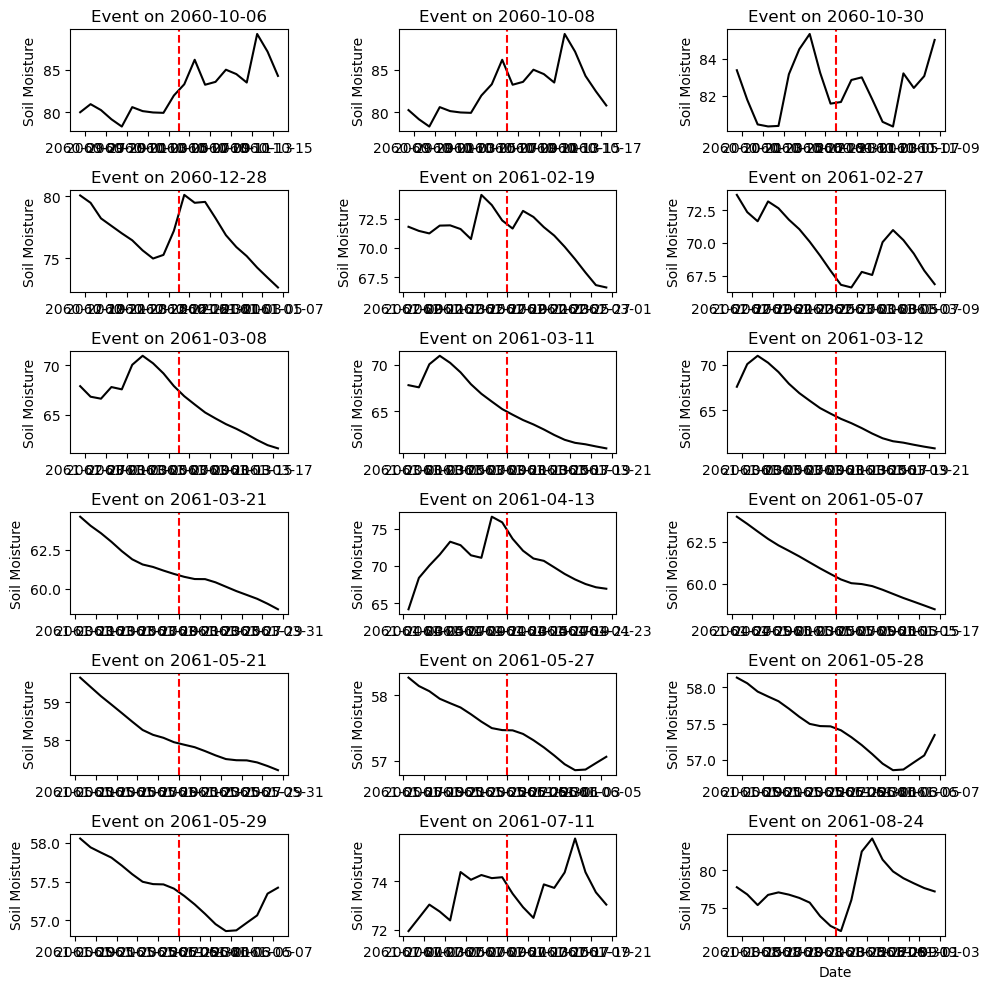

In [92]:
year = 2062

origin = pd.Timestamp("1970-01-01")

# Get events for that year
one_year_events = events[events['start_year'] == year].copy()

# Ensure datetime format
daily_means['dates'] = pd.to_datetime(daily_means['dates'])

n_events = len(one_year_events)

if n_events == 0:
    print("No events in this year.")
else:
    
    fig, axes = plt.subplots(int(n_events/3), 3, figsize=(10, 10), sharex=False)
    axes = axes.flatten()
    
    # If only one event, axes is not a list
    if n_events == 1:
        axes = [axes]
    
    for ax, (_, event_row) in zip(axes, one_year_events.iterrows()):
        
        event_date = event_row['start_date']
        
        # Define window
        start_window = event_date - pd.Timedelta(days=10)
        end_window   = event_date + pd.Timedelta(days=10)
        
        # Subset soil moisture
        window_data = daily_means[
            (daily_means['dates'] >= start_window) &
            (daily_means['dates'] <= end_window)
        ]
        
        # Plot
        ax.plot(window_data['dates'], window_data['daily_means'], color='black')
        ax.axvline(event_date, color='red', linestyle='--')
        
        ax.set_ylabel("Soil Moisture")
        ax.set_title(f"Event on {event_date.date()}")
    
    axes[-1].set_xlabel("Date")
    
    plt.tight_layout()
    plt.show()

For multiple years

date which breaks rules


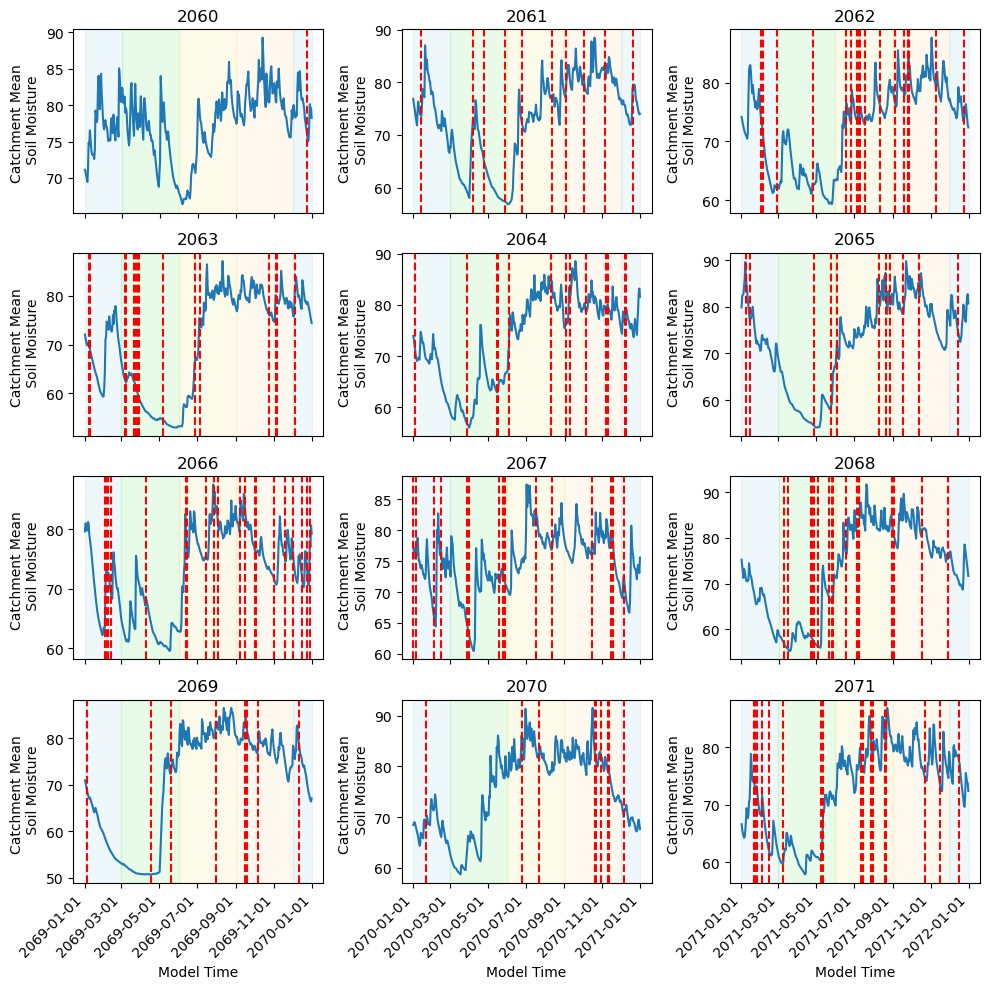

In [72]:
fig,axs=plt.subplots(ncols=3, nrows=4, figsize=(10,10))
axs=axs.flatten()
for ax_num, year in enumerate(range(2060,2072)):
    # Get data for just this year
    one_year = daily_means[daily_means['year']==year]
    
    # Plot event
    axs[ax_num].plot(one_year['dates'], one_year['daily_means'])
    
    # Label Axes
    axs[ax_num].set_xlabel("Model Time")
    axs[ax_num].set_ylabel("Catchment Mean \n Soil Moisture")

    # # Define season boundaries
    winter_start = pd.Timestamp(f"{year}-01-01")
    spring_start = pd.Timestamp(f"{year}-03-01")
    summer_start = pd.Timestamp(f"{year}-06-01")
    autumn_start = pd.Timestamp(f"{year}-09-01")
    winter2_start = pd.Timestamp(f"{year}-12-01")
    next_year_start = pd.Timestamp(f"{year+1}-01-01")

    # Add shaded regions
    axs[ax_num].axvspan(winter_start, spring_start, color='lightblue', alpha=0.2)
    axs[ax_num].axvspan(spring_start, summer_start, color='lightgreen', alpha=0.2)
    axs[ax_num].axvspan(summer_start, autumn_start, color='khaki', alpha=0.2)
    axs[ax_num].axvspan(autumn_start, winter2_start, color='navajowhite', alpha=0.2)
    axs[ax_num].axvspan(winter2_start, next_year_start, color='lightblue', alpha=0.2)

    # Add event lines
    axs[ax_num].set_xticks(axs[ax_num].get_xticks())
    axs[ax_num].set_xticklabels(axs[ax_num].get_xticklabels(), rotation=45, ha='right')
    
    axs[ax_num].set_title(year)
    
    one_year_events = events[events['start_year']==year].copy()
    event_dates= one_year_events['start_date']
    if len(event_dates) >0:
        for event in event_dates:
            try:
                axs[ax_num].axvline(event, color = 'red', linestyle='--');
            except:
                print("date which breaks rules")
    fig.autofmt_xdate(rotation=45)
fig.tight_layout()

### Get rainfall event data

In [56]:
# os.listdir("/scratch/hydro4/users/ld14116/5km_grid/Rainfall_events/Events_duration_ensemble_monthly_threshold_varying_95th")
events =pd.read_csv("/scratch/hydro4/users/ld14116/5km_grid/Rainfall_events/Events_duration_ensemble_monthly_threshold_varying_95th/NorthEastEngland_Ens_04_2060-2080_full_events.csv")
one_year_events = events[events['start_year']==2061]

In [69]:
events['start_date'] = [cftime.Datetime360Day(y, m, d, h)
                for y, m, d, h in zip(events['start_year'], events['start_month'], events['start_day'], events['start_hour'])]
events['stop_date'] = [cftime.Datetime360Day(y, m, d, h)
                for y, m, d, h in zip(events['stop_year'], events['stop_month'], events['stop_day'], events['stop_hour'])]

In [78]:
events.columns

Index(['Year', 'Month', 'Day', 'Hour', 'Pr', 'Index', 'start_indices',
       'stop_indices', 'duration', 'start_year', 'start_month', 'start_day',
       'start_hour', 'stop_year', 'stop_month', 'stop_day', 'stop_hour',
       'start_date', 'stop_date'],
      dtype='object')

In [52]:
# events =pd.read_csv(home_dir + "kv25483/FutureFlood/Data/NewcastleExample/flooded_area/Ens01_23/Tyne(Northumberland)_01_full_events_with_event_nums_flooded_area.csv")
# events['date'] = pd.to_datetime(dict(year=events['start_year'], month=events['start_month'],day=events['start_day']))

# one_year_events = events[events['start_year']==2062]
# one_year_events

## Find catchment mean soil moisture over different time periods
#### Add extra time variables

In [28]:
iris.coord_categorisation.add_season(model_cube, 'time', name='clim_season')
iris.coord_categorisation.add_month(model_cube, 'time', name='month')
iris.coord_categorisation.add_year(model_cube, 'time', name='year')
iris.coord_categorisation.add_season_year(model_cube, 'time', name='season_year')

#### Aggregate by extra time variables

In [70]:
seasonal_mean = model_cube.aggregated_by(['clim_season', 'season_year'], iris.analysis.MEAN)
monthly_mean = model_cube.aggregated_by(['month', 'year'], iris.analysis.MEAN)

### Find catchment mean over extra time variables (e.g., month, season, year)
This ends up with slightly odd looking dates, i.e. for month they are not always the first day of the month. This is because of the way the create_datetimes_dates_from_cube function is working (using 'h' since the origin), and because months aren't all consistent lengths [I think]. But for current purposes I think this is fine

In [71]:
# Monthly
catchment_monthly_mean = np.nanmean(np.where(mask, monthly_mean.data, np.nan), axis=(1, 2))
catchment_monthly_dates = create_datetime_dates_from_cube(monthly_mean)
# Seasonal
catchment_seasonal_mean = np.nanmean(np.where(mask, seasonal_mean.data, np.nan), axis=(1, 2))
catchment_seasonal_dates = create_datetime_dates_from_cube(seasonal_mean)

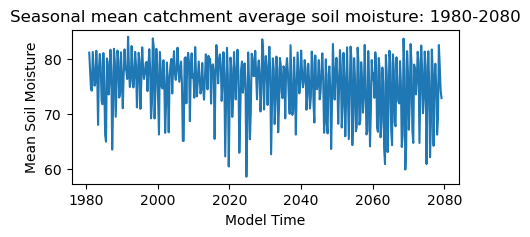

In [72]:
plt.figure(figsize=(5,2))
plt.plot(catchment_seasonal_dates, catchment_seasonal_mean)
plt.xlabel("Model Time")
plt.ylabel("Mean Soil Moisture")
plt.title("Seasonal mean catchment average soil moisture: 1980-2080")
plt.show()

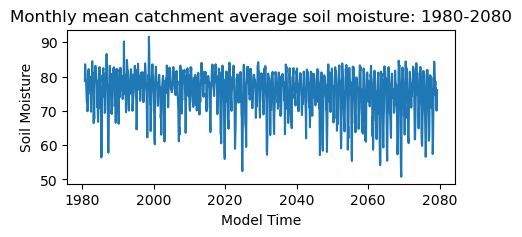

In [73]:
plt.figure(figsize=(5,2))
plt.plot(catchment_monthly_dates, catchment_monthly_mean)
plt.xlabel("Model Time")
plt.ylabel("Soil Moisture")
plt.title("Monthly mean catchment average soil moisture: 1980-2080")
plt.show()

## Relate soil moisture to other variables